(2000, 40)
(2000,)


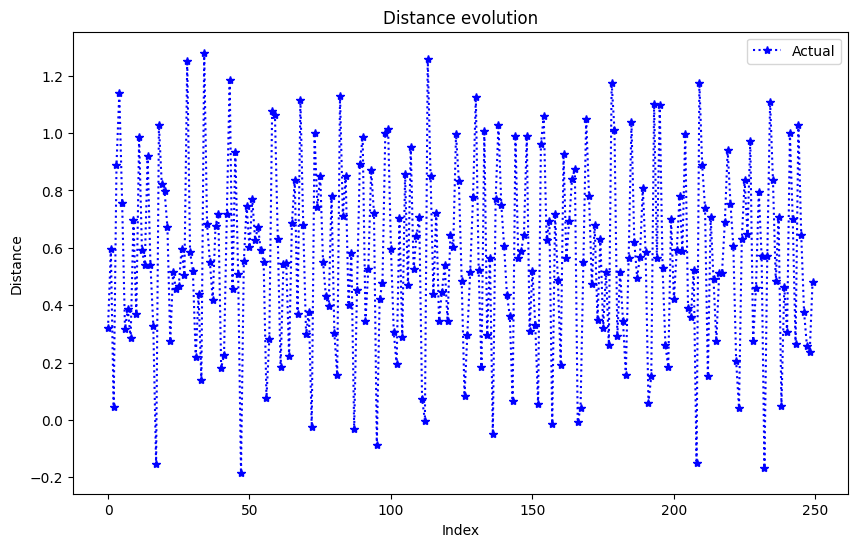

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

os.makedirs('../results/data_analysis_oshank', exist_ok=True)


X = pd.read_csv("../dataset/o_shank.csv").to_numpy()[1000:3000]
y = pd.read_csv("../dataset/distances.csv").iloc[:, 1].to_numpy()[1000:3000]

print(X.shape)
print(y.shape)


limit = 250
plt.figure(figsize=(10, 6))
plt.plot(range(len(y[:limit])), y[:limit], 'b:*', label='Actual')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.title('Distance evolution')
plt.legend()
plt.show()

# Feature selection

Ensemble Feature Selection (ou Feature Selection by Rank Aggregation)
combinar rankings de múltiplos métodos para obter um ranking consensual mais robusto

Amostras: 2000 | Features: 40
Target: mean=0.5283, std=0.2983



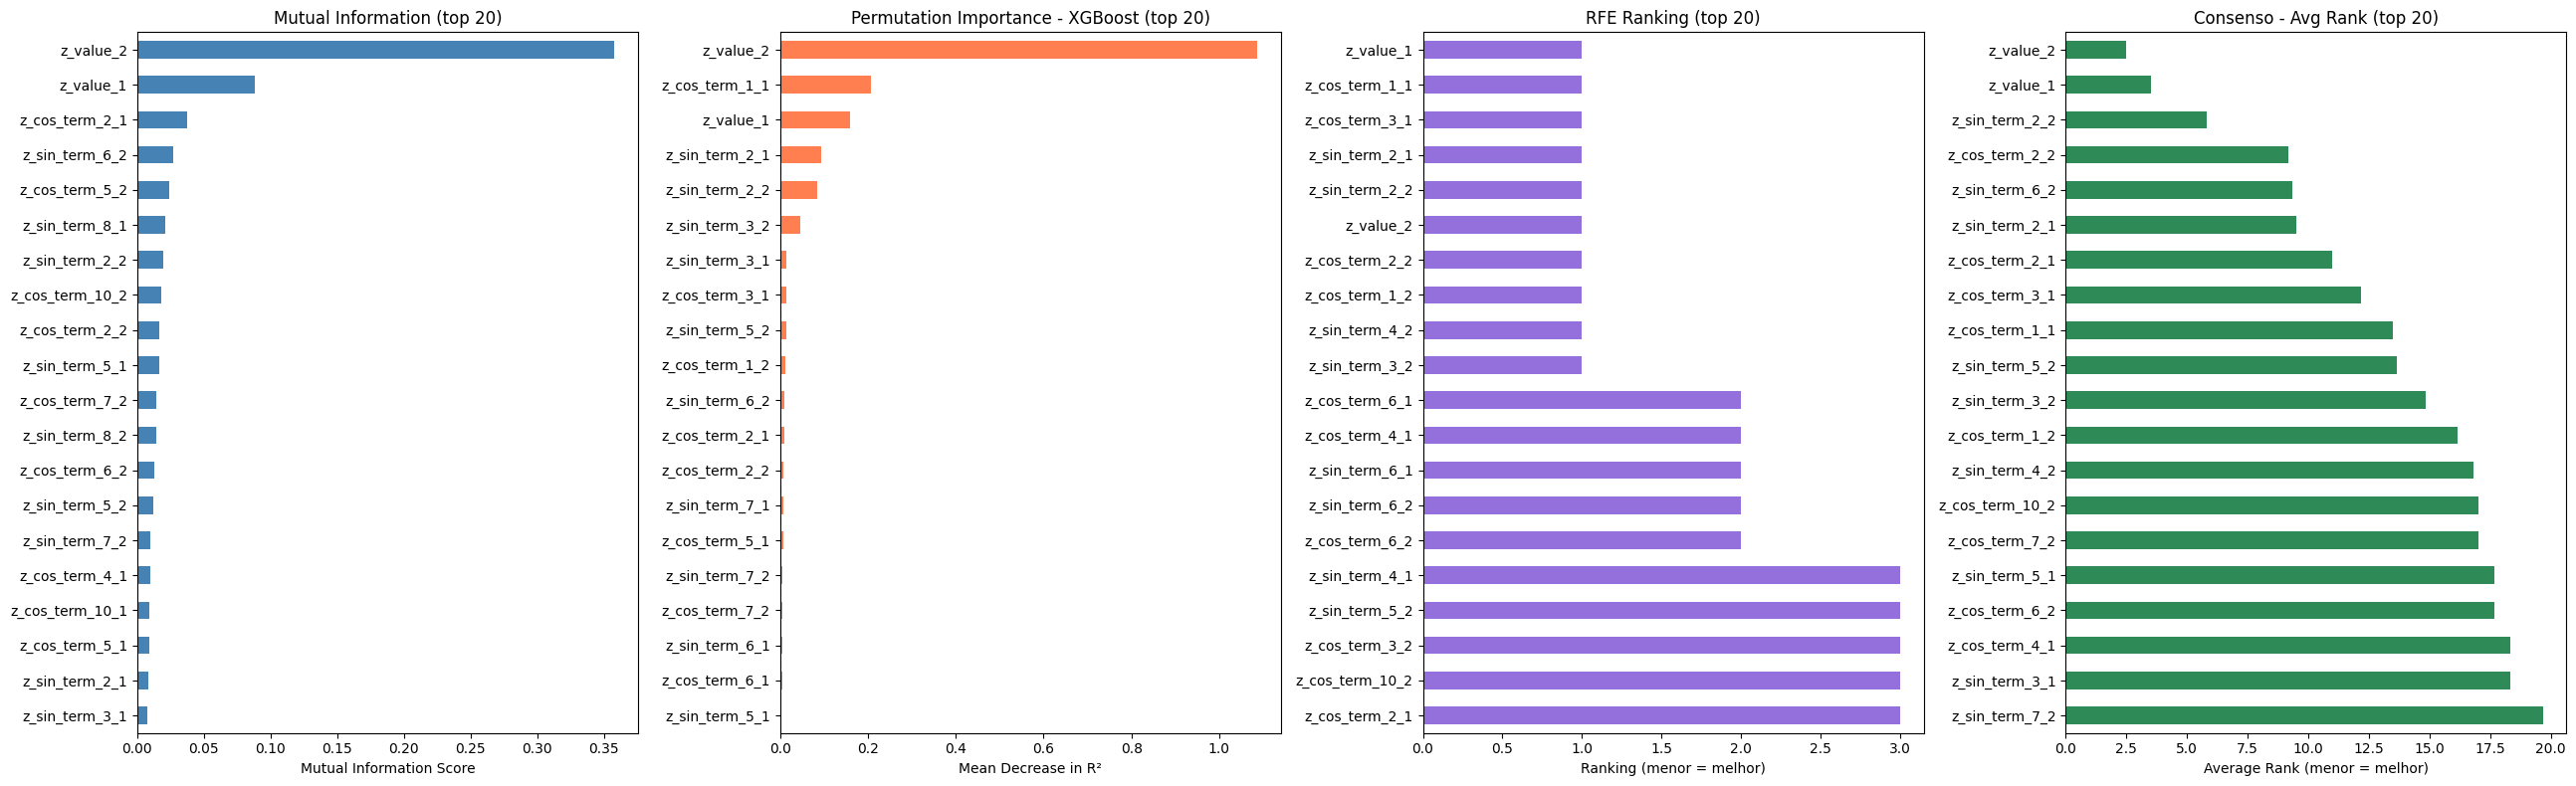


Salvos: selected_features.csv, feature_ranking_full.csv


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

X = pd.read_csv("../dataset/o_shank.csv").to_numpy()[1000:3000]
y = pd.read_csv("../dataset/distances.csv").iloc[:, 1].to_numpy()[1000:3000]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

features = pd.read_csv("../dataset/o_shank.csv").columns.tolist()

print(f"Amostras: {X.shape[0]} | Features: {X.shape[1]}")
print(f"Target: mean={y.mean():.4f}, std={y.std():.4f}\n")

mi = mutual_info_regression(X_tr, y_tr, random_state=42, n_neighbors=5)
mi = pd.Series(mi, index=features).sort_values(ascending=False)

xgb = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, random_state=42, n_jobs=-1
)
xgb.fit(X_tr, y_tr)

perm = permutation_importance(xgb, X_te, y_te, n_repeats=15, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)


rfe_model = XGBRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, random_state=42, n_jobs=-1
)
rfe = RFE(rfe_model, n_features_to_select=10, step=5)
rfe.fit(X_tr, y_tr)
rfe_ranking = pd.Series(rfe.ranking_, index=features).sort_values()

mi_ranks = mi.rank(ascending=False)
perm_ranks = perm_imp.rank(ascending=False)
rfe_ranks = rfe_ranking.rank(ascending=True)

consensus = pd.DataFrame({
    'MI': mi_ranks,
    'Permutation': perm_ranks,
    'RFE': rfe_ranks
})
consensus['avg_rank'] = consensus.mean(axis=1)
consensus = consensus.sort_values('avg_rank')

selected = consensus.head(10).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(26, 8))

mi.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Mutual Information (top 20)')
axes[0].set_xlabel('Mutual Information Score')
axes[0].invert_yaxis()

perm_imp.head(20).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Permutation Importance - XGBoost (top 20)')
axes[1].set_xlabel('Mean Decrease in R²')
axes[1].invert_yaxis()

rfe_ranking.head(20).plot(kind='barh', ax=axes[2], color='mediumpurple')
axes[2].set_title('RFE Ranking (top 20)')
axes[2].set_xlabel('Ranking (menor = melhor)')
axes[2].invert_yaxis()

consensus['avg_rank'].head(20).plot(kind='barh', ax=axes[3], color='seagreen')
axes[3].set_title('Consenso - Avg Rank (top 20)')
axes[3].set_xlabel('Average Rank (menor = melhor)')
axes[3].invert_yaxis()

plt.tight_layout()
plt.show()

pd.DataFrame({'feature': selected}).to_csv('../results/data_analysis_oshank/selected_features.csv', index=False)
consensus.to_csv('../results/data_analysis_oshank/feature_ranking_full.csv')
print(f"\nSalvos: selected_features.csv, feature_ranking_full.csv")

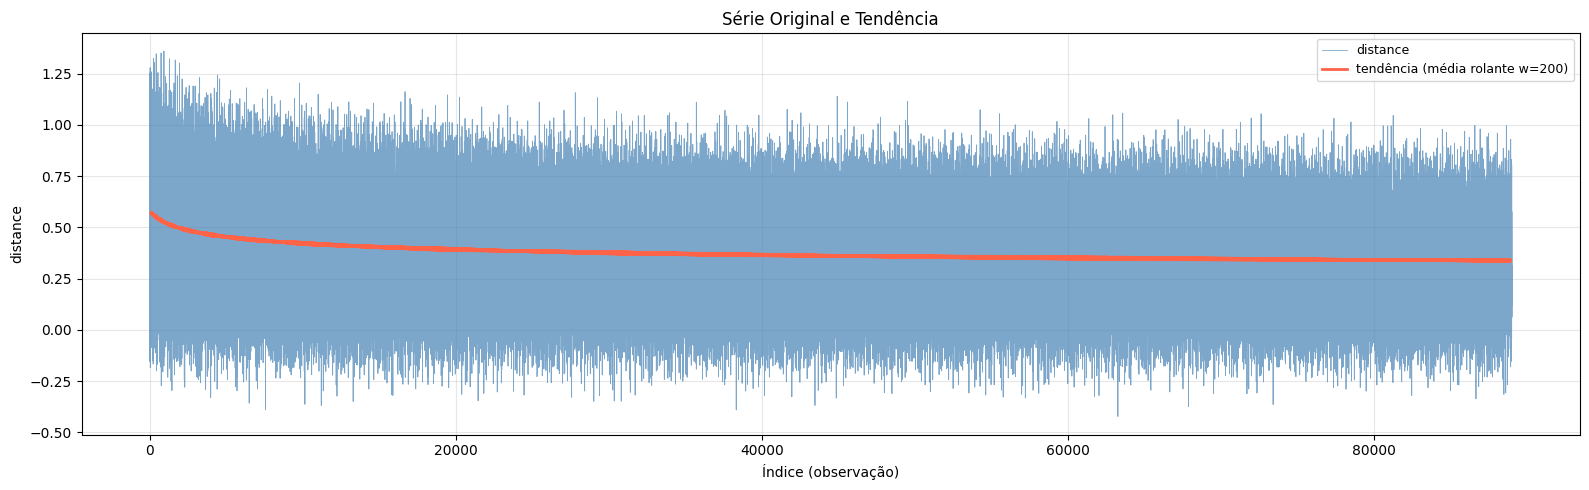

In [ ]:
TARGET = 'distance'
DATA_PATH = '../dataset/riemann_features.csv'

df = pd.read_csv(DATA_PATH)
series = df[TARGET].copy()

window = 200
trend = series.rolling(window, center=True).mean()

plt.figure(figsize=(16, 5))

plt.plot(series, lw=0.6, alpha=0.7, color='steelblue', label='distance')
plt.plot(trend, color='tomato', lw=2, label=f'tendência (média rolante w={window})')
plt.title('Série Original e Tendência')
plt.xlabel('Índice (observação)')
plt.ylabel('distance')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/data_analysis/trend.png', dpi=150, bbox_inches='tight')
plt.show()

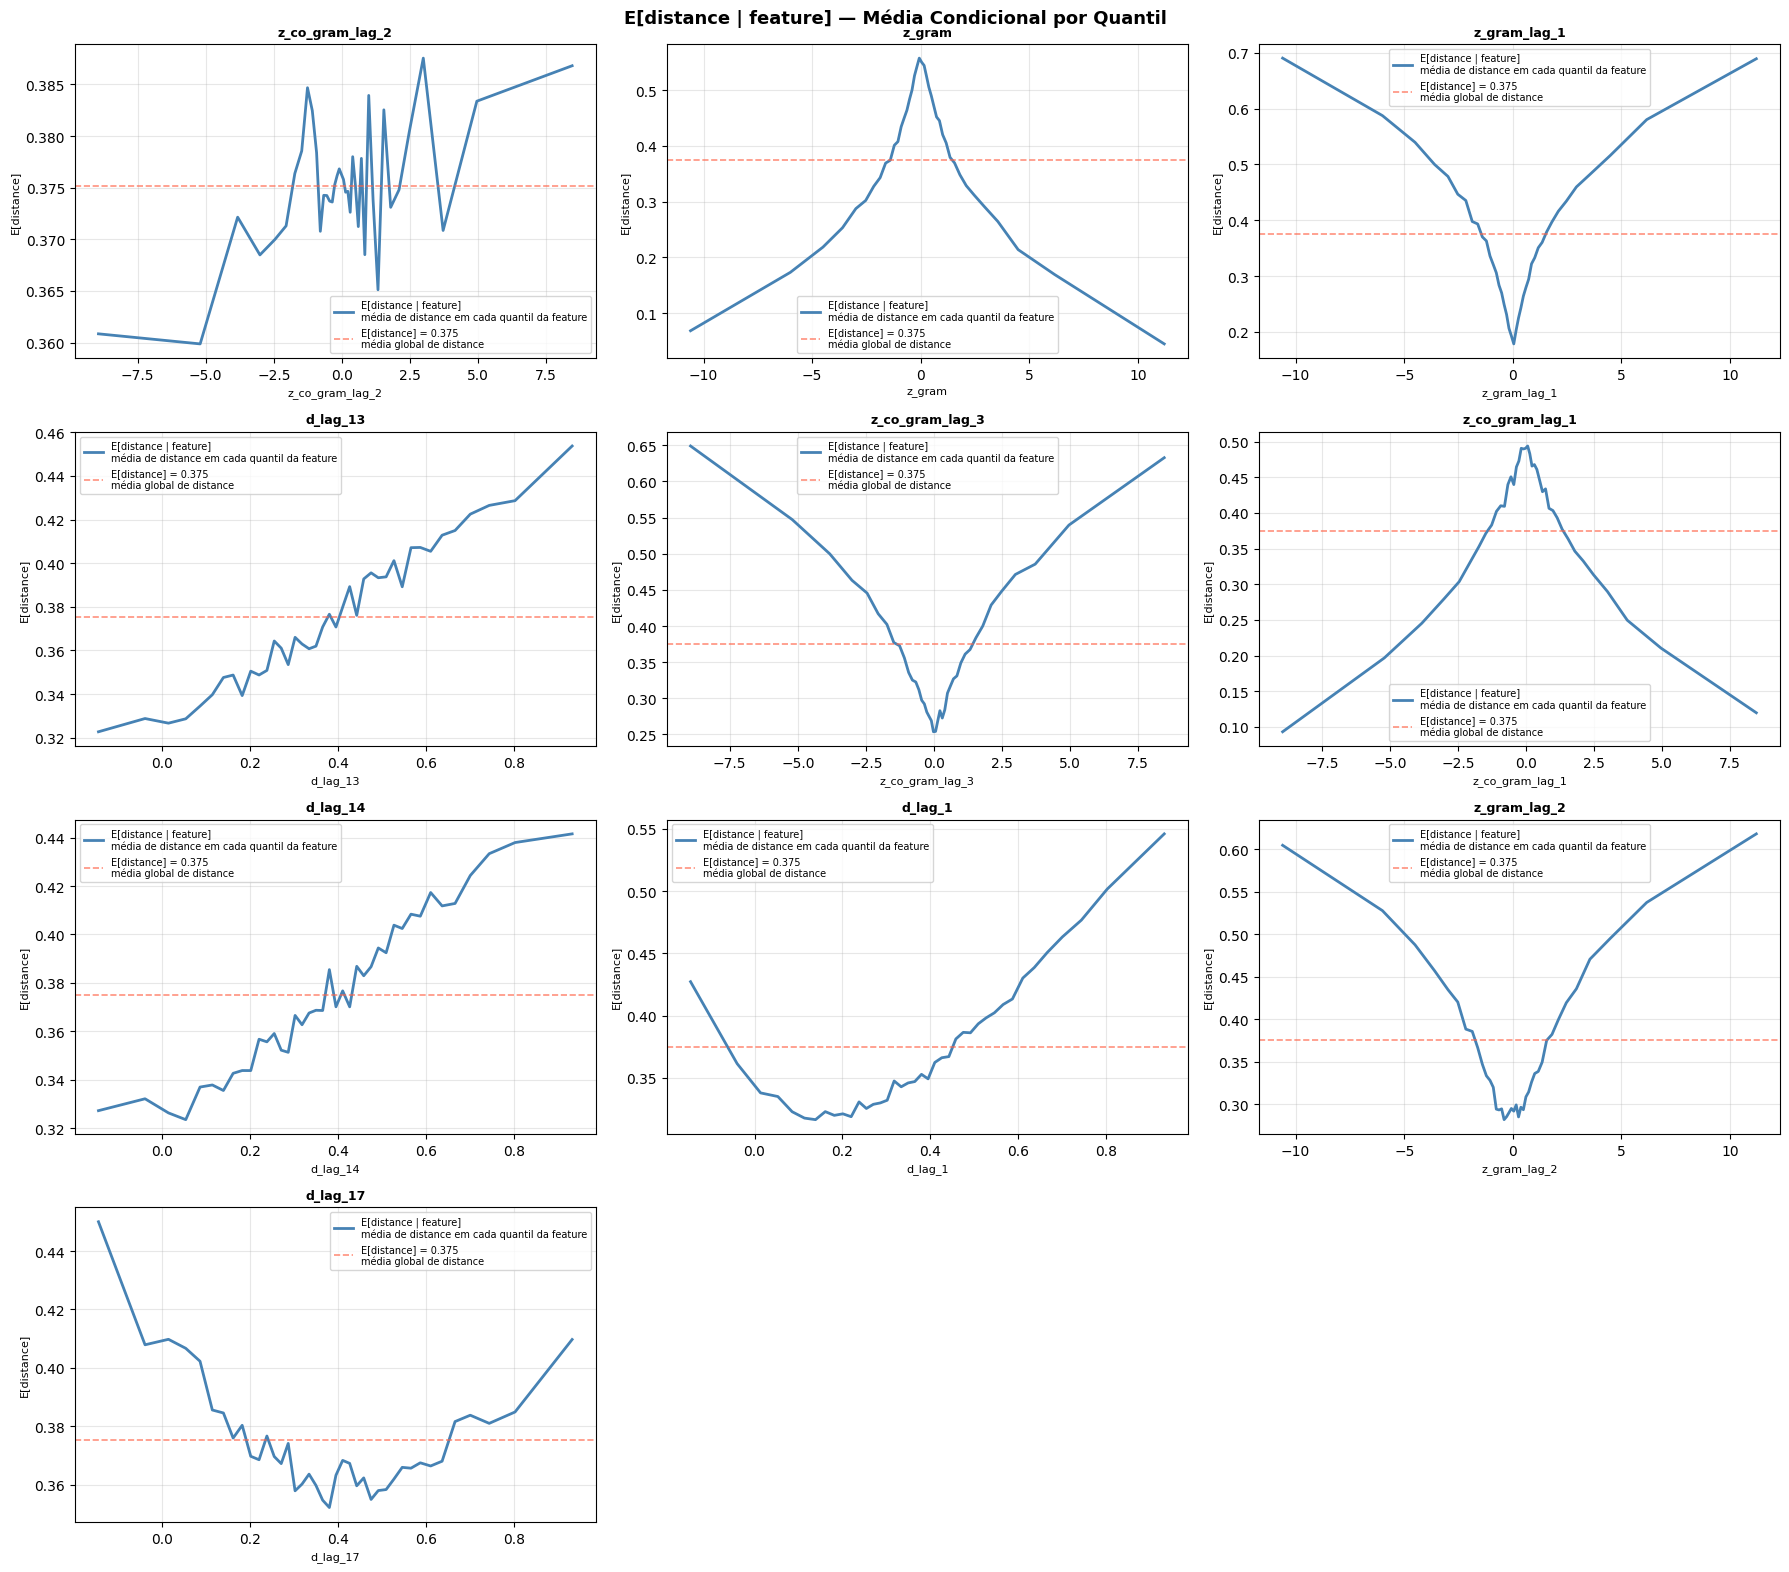

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TARGET = 'distance'
DATA_PATH = '../dataset/riemann_features.csv'
SELECTED_PATH = '../results/data_analysis/selected_features.csv'

df = pd.read_csv(DATA_PATH)
selected = pd.read_csv(SELECTED_PATH)['feature'].tolist()
cols = selected + [TARGET]
df = df[cols].copy()

n_cols = 3
n_rows = int(np.ceil(len(selected) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle('E[distance | feature] — Média Condicional por Quantil', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(selected):
    ax = axes[i]

    x = df[feat].to_numpy()
    y = df[TARGET].to_numpy()

    df_bin = pd.DataFrame({'x': x, 'y': y})
    df_bin['bin'] = pd.qcut(df_bin['x'], q=40, duplicates='drop')
    grouped = df_bin.groupby('bin')['y'].mean()
    bin_centers = df_bin.groupby('bin')['x'].mean()

    ax.plot(bin_centers, grouped, color='steelblue', lw=2,
            label='E[distance | feature]\nmédia de distance em cada quantil da feature')
    ax.axhline(y.mean(), color='tomato', lw=1.2, ls='--', alpha=0.7,
               label=f'E[distance] = {y.mean():.3f}\nmédia global de distance')

    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel(f'E[{TARGET}]', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../results/data_analysis/conditional_mean.png', dpi=150, bbox_inches='tight')
plt.show()